# 🏠 House Price Prediction

## Project Overview

This project focuses on **house price prediction** using a publicly available **Kaggle dataset**. The primary objective is to understand the **end-to-end process of training machine learning models**, from data preprocessing to model evaluation.

## Objectives

* Understand the structure and characteristics of real-world housing data
* Perform data cleaning and exploratory data analysis (EDA)
* Train and evaluate different machine learning models
* Compare model performance using appropriate metrics

## Dataset

* Source: **Kaggle**
* Type: Structured tabular data
* Target Variable: **House Price**

## Technologies Used

* Python
* NumPy
* Pandas
* Matplotlib / Seaborn
* Scikit-learn

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("HousePricePrediction.csv")

df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

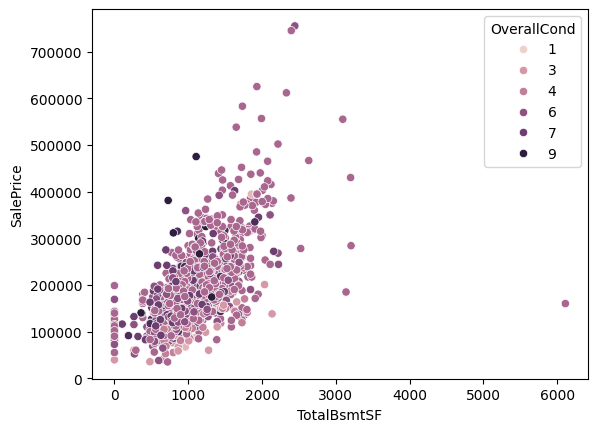

In [41]:
#visiulation part

sns.scatterplot(x= df["TotalBsmtSF"],y=df["SalePrice"] ,hue=df["OverallCond"])

In [42]:
random = df["BsmtFinSF2"].sample(10)

print(random)

2519      0.0
810     377.0
578       0.0
1316      0.0
1028     41.0
1578      0.0
517       0.0
1865      0.0
488       0.0
2041      0.0
Name: BsmtFinSF2, dtype: float64


In [ ]:
#dropping id ans bsmt2 section

df = df.drop(columns = ["Id" , "YearRemodAdd"])


In [44]:
df.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,Exterior1st,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,VinylSd,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,MetalSd,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,VinylSd,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,Wd Sdng,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,VinylSd,1145.0,250000.0


In [45]:

#drop NaN values
df = df.dropna(subset=['SalePrice'])

#seperating input and output features
X = df.drop('SalePrice' , axis = 1)
Y = df["SalePrice"] 

X.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,Exterior1st,TotalBsmtSF
0,60,RL,8450,Inside,1Fam,5,2003,VinylSd,856.0
1,20,RL,9600,FR2,1Fam,8,1976,MetalSd,1262.0
2,60,RL,11250,Inside,1Fam,5,2001,VinylSd,920.0
3,70,RL,9550,Corner,1Fam,5,1915,Wd Sdng,756.0
4,60,RL,14260,FR2,1Fam,5,2000,VinylSd,1145.0


In [46]:
# one hot endcoding 
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X,columns = cat_cols,drop_first = True)

TF_cols = X.select_dtypes(include=['bool']).columns
X[TF_cols] = X[TF_cols].astype(int)



In [47]:
X.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LotConfig_CulDSac,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,856.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,20,9600,8,1976,1262.0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,60,11250,5,2001,920.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,70,9550,5,1915,756.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,60,14260,5,2000,1145.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [48]:
#traning model importing sklearn

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42)

In [49]:
#traning liner regration model
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, Y_train)

In [50]:
Y_pred = reg.predict(X_test)

Y_pred

array([158571.1896679 , 229634.19271772, 127904.21462505, 189539.98572219,
       247646.81817802, 186079.06720092, 173198.22273317, 123197.17018505,
       156360.9308013 , 171078.54554193, 146721.83481243, 131210.7595171 ,
        96779.88076183, 234667.03408681, 217020.69161835, 159336.94254177,
       214523.95276774, 165418.24151657, 141236.20611881, 228863.53426602,
       145992.43704986, 223347.07896251, 200360.76112095, 148732.70741894,
       221994.65155206, 162401.32230866, 222829.26113141, 130963.25374332,
       212530.55950511, 208871.62876398,  96330.22601592, 227587.30946223,
       216235.33484783, 157523.55444182, 243903.91788504, 149394.93840969,
       170456.72918581, 214034.2084771 , 255563.39226548,  91410.80572686,
       132389.52722396, 213331.08353347, 132132.33120107, 282144.52962607,
       148702.2420769 ,  94588.83559828, 144355.53434482, 144003.54143115,
       313052.28058983, 157681.10130133, 138679.7367501 , 194215.38957918,
       144266.60130492, 2

In [51]:
from sklearn.metrics import r2_score

r2_score(Y_test, Y_pred)


0.5939998879715755